## 0. 라이브러리 생성, 데이터 불러오기, 데이터 기본 정보 확인

In [90]:
import numpy as np                  # 수치 계산/벡터·행렬 연산(NumPy)
import pandas as pd                 # 데이터프레임 생성·가공·요약(Pandas)

import matplotlib.pyplot as plt     # 기본 시각화 라이브러리(Matplotlib)
plt.rc('font', family='Malgun Gothic')  # 한글 폰트 설정(그래프에서 한글 깨짐 방지)
 
import koreanize_matplotlib         # Matplotlib 한글 폰트/마이너스 기호 등 자동 설정

from IPython.display import display # 노트북에서 DataFrame 등을 예쁘게 출력할 때 사용

import seaborn as sns               # 통계 시각화(분포/관계/범주형 비교) 라이브러리(Seaborn)

from scipy.stats import chi2_contingency # 카이제곱 검정

In [91]:
# 데이터 불러오기
data = pd.read_csv("Titanic-Dataset.csv") 
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [92]:
# 위에서 5행 보기
data.head() 

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [93]:
# 아래에서 5행 보기
data.tail() 

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [94]:
# 행 개수, 열 개수
data.shape  

(891, 12)

In [95]:
# 변수(열) 이름 목록
data.columns 

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [96]:
# 변수별 자료형
data.dtypes 

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

In [97]:
# 숫자형 변수의 요약통계량

numeric_data = data.select_dtypes(include='number') # 숫자형 변수만 추출

numeric_data.describe()  

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [98]:
# 변수별 고유값 개수 → 범주형인지 추측
data.nunique() 

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

In [99]:
# 변수별 결측치 개수
data.isnull().sum() 

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [100]:
# 모든 변수가 다 NA인 행
data.isnull().all(axis=1) #

0      False
1      False
2      False
3      False
4      False
       ...  
886    False
887    False
888    False
889    False
890    False
Length: 891, dtype: bool

In [101]:
# 모든 변수가 다 NA인 행 개수
data.isna().all(axis=1).sum() 

np.int64(0)

# 🎯 제출 과제

아래 두 과제를 이 노트북 안에서 완성해서 제출하세요. 위에서 배운 함수들을 활용하면 됩니다.

## 과제 1. 생존과 연관된 변수 찾기
- 추가 EDA를 진행해 **`Survived`와 관련이 깊은 변수**를 찾고, 그렇게 판단한 근거를 정리하세요.
- 단순히 그래프만 그리지 말고 **가설검정·통계분석**(예: 교차표 + 카이제곱검정, 그룹별 평균 비교 등)으로 뒷받침해 보세요.
- 발견한 내용을 마크다운 셀에 **인사이트(insight)** 로 3줄 이상 정리하세요.

## 과제 2. Age 결측값 채우기
- `Age`에는 결측치가 많습니다. 이를 **합리적인 방법으로 채워** 보세요.
- 단순 평균/중앙값으로 채우는 것보다, 아래 **이름(Name)의 호칭**을 활용하면 더 정교하게 채울 수 있습니다.
- 왜 그 방법을 골랐는지 근거도 함께 적으세요.

> 아래 셀들은 과제 2의 힌트입니다. 이름에서 호칭(Mr, Miss, Mrs, Master 등)을 뽑아내는 데 참고하세요.

## 과제 1. 생존과 연관된 변수 찾기

In [102]:
# 원본을 복사해서 사용
data1 = data.copy()
data1.head()

# 성별과 생존 여부 교차표
sex_table = pd.crosstab(data["Sex"], data1["Survived"])
sex_table

Survived,0,1
Sex,,
female,81,233
male,468,109


Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


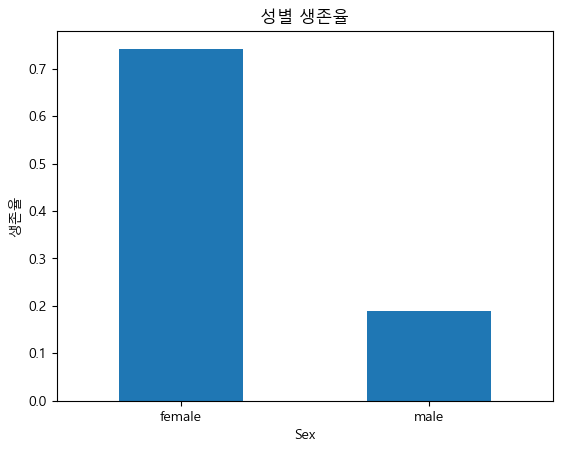

In [103]:
# 성별 생존율 확인
sex_survival_rate = data1.groupby("Sex")["Survived"].mean()
print(sex_survival_rate)

# 막대그래프
sex_survival_rate.plot(kind="bar", rot=0)
plt.title("성별 생존율")
plt.ylabel("생존율")
plt.show()


# 여성(female) : 0.7420
# 남성(male)   : 0.1889 으로 성별간 생존율의 차이가 있는 것으로 의심된다.

## 성별과 생존 여부 카이제곱검정

- p-value가 0.05 보다 작으면 성별과 생존 여부가 관련 있다고 판단

In [ ]:
# 카이제곱검정
# H0 : 성별과 생존 여부는 서로 관련이 없다. (남성과 여성의 생존 비율은 동일하다.)
# H1 : 성별과 생존 여부는 서로 관련이 있다. (남성과 여성의 생존 비율은 다르다.)

chi2, p_value, dof, expected = chi2_contingency(sex_table)

print("카이제곱 통계량:", chi2)
print("p-value:", p_value)

if p_value < 0.05:
    print("성별과 생존 여부는 관련이 있다고 볼 수 있다.")
else:
    print("성별과 생존 여부는 관련이 없다고 볼 수 있다.")


카이제곱 통계량: 260.71702016732104
p-value: 1.1973570627755645e-58
성별과 생존 여부는 관련이 있다고 볼 수 있다.


In [105]:
# 객실 등급과 생존 여부 교차표 (그룹별 평균 비교)
class_table = pd.crosstab(data1["Pclass"], data1["Survived"])
class_table

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


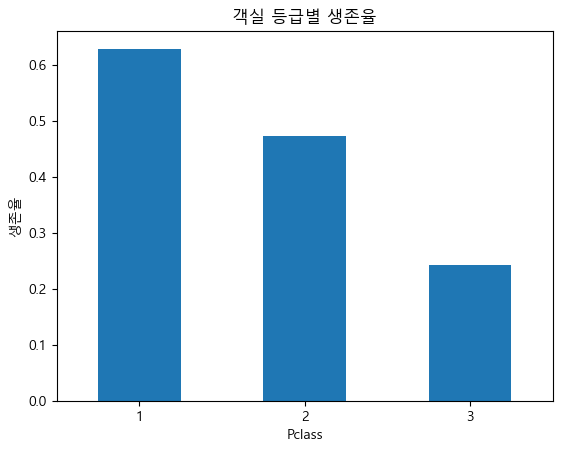

In [106]:
# 객실 등급별 생존율
class_survival_rate = data1.groupby("Pclass")["Survived"].mean()
print(class_survival_rate)

class_survival_rate.plot(kind="bar", rot=0)
plt.title("객실 등급별 생존율")
plt.ylabel("생존율")
plt.show()


In [107]:
# 객실 등급과 생존 여부 카이제곱검정
# H0 : 객실 등급과 생존 여부는 서로 관련이 없다. (1등급, 2등급, 3등급의 생존 비율은 동일하다.)
# H1 : 객실 등급과 생존 여부는 서로 관련이 있다. (세 객실 등급 중 적어도 하나의 생존 비율이 다르다.)

chi2, p_value, dof, expected = chi2_contingency(class_table)

print("카이제곱 통계량:", chi2)
print("p-value:", p_value)

if p_value < 0.05:
    print("객실 등급과 생존 여부는 관련이 있다고 볼 수 있다.")
else:
    print("객실 등급과 생존 여부는 관련이 없다고 볼 수 있다.")


카이제곱 통계량: 102.88898875696056
p-value: 4.549251711298793e-23
객실 등급과 생존 여부는 관련이 있다고 볼 수 있다.


## 과제 1 인사이트

1. 성별 생존율을 확인했을 때 여성의 생존율이 남성보다 훨씬 높게 나타났다.  
2. 성별과 생존 여부의 카이제곱검정 결과 p-value가 0.05보다 작아서 두 변수는 관련이 있다고 판단하였다.  
3. 객실 등급별로도 생존율 차이가 있었고, 1등석 승객의 생존율이 3등석 승객보다 높았다.  
3-1.  3등석 승객의 생존율이 가장 낮게 나타난 점을 바탕으로, 3등석 객실이 많이 위치한 배 앞쪽부터 침몰했을 가능성이 있다고 의심해 볼 수 있다.
4. 따라서 확인한 변수 중에서는 성별과 객실 등급이 생존 여부와 관련이 깊다고 생각했습니다.

## 과제 2. Age 결측값 채우기
- `Age`에는 결측치가 많습니다. 이를 **합리적인 방법으로 채워** 보세요.
- 단순 평균/중앙값으로 채우는 것보다, 아래 **이름(Name)의 호칭**을 활용하면 더 정교하게 채울 수 있습니다.
- 왜 그 방법을 골랐는지 근거도 함께 적으세요.

**호칭별 의미 (Age 결측치 채우기에 활용)**
- **Mr** : 18세 이상 남성
- **Miss** : 미혼 여성
- **Mrs** : 기혼 여성
- **Master** : 13세 이하 남성 (남자아이)
- **Dr** : 박사·의사 등

> ✏️ **직접 해보기:** `data1['Name'].str.extract(...)` 등을 이용해 호칭만 뽑아 새 컬럼을 만들고, **호칭별 평균 나이**로 Age 결측치를 채워보세요.


In [108]:
# Age 결측치 개수 확인
print("채우기 전 Age 결측치 개수:", data1["Age"].isnull().sum())

# 원래 Age 값을 따로 저장
data1["Age_before"] = data1["Age"]


채우기 전 Age 결측치 개수: 177


In [109]:
data1.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_before
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,22.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,38.0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,26.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,35.0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,35.0


In [110]:
# 이름에서 호칭 뽑기
data1["Title"] = data1["Name"].str.extract(r',\s*([^.]*)\.')

# 잘 뽑혔는지 확인
data1[["Name", "Title"]].head()


,Name,Title
0,"Braund, Mr. Owen Harris",Mr
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs
2,"Heikkinen, Miss. Laina",Miss
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs
4,"Allen, Mr. William Henry",Mr


In [111]:
# 호칭별 인원수 확인
data1["Title"].value_counts()

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

In [112]:
# 호칭별 평균 나이 확인
title_age_mean = data1.groupby("Title")["Age"].mean()
title_age_mean


Title
Capt            70.000000
Col             58.000000
Don             40.000000
Dr              42.000000
Jonkheer        38.000000
Lady            48.000000
Major           48.500000
Master           4.574167
Miss            21.773973
Mlle            24.000000
Mme             24.000000
Mr              32.368090
Mrs             35.898148
Ms              28.000000
Rev             43.166667
Sir             49.000000
the Countess    33.000000
Name: Age, dtype: float64

In [122]:
# 호칭별 평균 나이로 Age 결측값 채우기
for title in title_age_mean.index:
    average_age = title_age_mean[title]

    condition = (data1["Title"] == title) & (data1["Age"].isnull())
    data1.loc[condition, "Age"] = average_age

# 혹시 남아 있는 결측치는 전체 평균으로 채우기
data1["Age"] = data1["Age"].fillna(data1["Age"].mean())

print("채운 후 Age 결측치 개수:", data1["Age"].isnull().sum())

채운 후 Age 결측치 개수: 0


In [114]:
# 실제로 채워진 행 일부 확인
data1[data1["Age_before"].isnull()][["Name", "Title", "Age_before", "Age"]].head(10)


,Name,Title,Age_before,Age
5,"Moran, Mr. James",Mr,NaN,32.368090
17,"Williams, Mr. Charles Eugene",Mr,NaN,32.368090
19,"Masselmani, Mrs. Fatima",Mrs,NaN,35.898148
26,"Emir, Mr. Farred Chehab",Mr,NaN,32.368090
28,"O'Dwyer, Miss. Ellen ""Nellie""",Miss,NaN,21.773973
29,"Todoroff, Mr. Lalio",Mr,NaN,32.368090
31,"Spencer, Mrs. William Augustus (Marie Eugenie)",Mrs,NaN,35.898148
32,"Glynn, Miss. Mary Agatha",Miss,NaN,21.773973
36,"Mamee, Mr. Hanna",Mr,NaN,32.368090
42,"Kraeff, Mr. Theodor",Mr,NaN,32.368090


In [127]:
# 호칭별 평균 나이 확인
Age_after = data1.groupby("Title")["Age"].mean()
Age_after

Title
Capt            70.000000
Col             58.000000
Don             40.000000
Dr              42.000000
Jonkheer        38.000000
Lady            48.000000
Major           48.500000
Master           4.574167
Miss            21.773973
Mlle            24.000000
Mme             24.000000
Mr              32.368090
Mrs             35.898148
Ms              28.000000
Rev             43.166667
Sir             49.000000
the Countess    33.000000
Name: Age, dtype: float64

In [128]:
# 전처리 전 호칭별 평균 나이 비교
Age_before = data1.groupby("Title")["Age_before"].mean()
Age_before

Title
Capt            70.000000
Col             58.000000
Don             40.000000
Dr              42.000000
Jonkheer        38.000000
Lady            48.000000
Major           48.500000
Master           4.574167
Miss            21.773973
Mlle            24.000000
Mme             24.000000
Mr              32.368090
Mrs             35.898148
Ms              28.000000
Rev             43.166667
Sir             49.000000
the Countess    33.000000
Name: Age_before, dtype: float64

In [ ]:
# 전처리 전 후 호칭별 평균 나이가 같은지 확인
Age_before.equals(Age_after)

True

## 과제 2 인사이트
1. 데이터의 이름에서 호칭별로 나이대가 다르다는 것을 알았다.
2. 그래서 전체 평균 하나로 채우는 것보다 호칭별 평균 나이로 채우는 것이 더 정확한 정보로 결측치를 처리하는 것이라 생각하였다.  
3. 호칭별 평균으로 채운 뒤에도 남는 결측값이 있을 수 있어서 마지막에는 전체 평균으로 한 번 더 채웠다. 